# EDA du dataset BTGenBot

Ce notebook analyse le dataset BTGenBot avant toute conversion JSONL et avant le fine-tuning QLoRA. L'objectif est de comprendre ce que le modèle devra apprendre : passer d'une description naturelle d'une tâche robotique à un Behavior Tree en XML.

L'EDA sert ici à vérifier la qualité du dataset, la validité syntaxique des XML, le vocabulaire des nœuds BT, la complexité des arbres, et les limites à anticiper pour un transfert vers NAV4RAIL/SNCF.

Rappel : chaque exemple contient une instruction générale, un `input` en langage naturel, et un `output` correspondant à un Behavior Tree XML.

In [1]:
import json
import re
import textwrap
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option('display.max_colwidth', 140)
plt.style.use('default')

In [2]:
def find_project_root(start=None):
    """Trouve la racine du projet depuis la racine repo ou depuis notebooks/."""
    current = Path.cwd() if start is None else Path(start)
    for candidate in [current, *current.parents]:
        if (candidate / 'dataset' / 'bt_dataset.json').exists():
            return candidate
    raise FileNotFoundError('Impossible de trouver dataset/bt_dataset.json')


PROJECT_ROOT = find_project_root()
DATASET_PATH = PROJECT_ROOT / 'dataset' / 'bt_dataset.json'

print(f'Racine projet : {PROJECT_ROOT}')
print(f'Dataset       : {DATASET_PATH}')

Racine projet : /home/mohamed/BTGenBot_Nav4Rails
Dataset       : /home/mohamed/BTGenBot_Nav4Rails/dataset/bt_dataset.json


## 1. Chargement du dataset

On charge le JSON original en lecture seule. Le but est de vérifier sa structure avant de préparer une éventuelle conversion JSONL.

In [3]:
with DATASET_PATH.open('r', encoding='utf-8') as f:
    raw_data = json.load(f)

if not isinstance(raw_data, list):
    raise TypeError(f'Le dataset devrait être une liste, pas {type(raw_data).__name__}')

df = pd.DataFrame(raw_data)
expected_columns = ['instruction', 'input', 'output']
missing_columns = [col for col in expected_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f'Colonnes manquantes : {missing_columns}')

df = df[expected_columns].copy()

print(f'Nombre d exemples : {len(df)}')
print(f'Champs disponibles : {list(df.columns)}')
df.head(3)

Nombre d exemples : 594
Champs disponibles : ['instruction', 'input', 'output']


,instruction,input,output
0,"You will be provided a summary of a task performed by a behavior tree, and your objective is to express this behavior tree in XML format.",The behavior tree orchestrates the navigation of a robot by periodically replanning its global path at a frequency of 1 Hz. It utilizes ...,"<!--\n This Behavior Tree replans the global path periodically at 1 Hz.\n-->\n\n<root main_tree_to_execute=""MainTree"">\n <BehaviorTree..."
1,"You will be provided a summary of a task performed by a behavior tree, and your objective is to express this behavior tree in XML format.",The behavior tree is designed to control a robot's navigation with continuous replanning of the global path. It uses a pipeline sequence...,"<!--\n This Behavior Tree replans the global path after every 1m.\n-->\n\n<root main_tree_to_execute=""MainTree"">\n <BehaviorTree ID=""M..."
2,"You will be provided a summary of a task performed by a behavior tree, and your objective is to express this behavior tree in XML format.",The behavior tree is a simple sequential task for a robot. It first instructs the robot to move to a specific point (Go_point) and then ...,"<root main_tree_to_execute = ""MainTree"" >\n <BehaviorTree ID=""MainTree"">\n <Sequence name=""root_sequence"">\n <Go_poin..."


In [4]:
EXPECTED_N_EXAMPLES = 594

quality_table = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'empty_strings': df.apply(lambda col: col.astype(str).str.strip().eq('').sum()),
    'unique_values': df.nunique(dropna=True),
})

print(f'Nombre d exemples observé : {len(df)}')
print(f'Nombre d exemples attendu dans cette EDA : {EXPECTED_N_EXAMPLES}')
quality_table

Nombre d exemples observé : 594
Nombre d exemples attendu dans cette EDA : 594


,dtype,missing_values,empty_strings,unique_values
instruction,str,0,0,1
input,str,0,0,594
output,str,0,0,454


In [5]:
def show_examples(frame, indices=(0, 1, 2), output_chars=900):
    """Affiche quelques exemples sans imprimer des XML trop longs."""
    for idx in indices:
        row = frame.iloc[idx]
        print('=' * 100)
        print(f'Exemple {idx}')
        print('- Instruction')
        print(textwrap.fill(str(row['instruction']), width=100))
        print('\n- Input naturel')
        print(textwrap.fill(str(row['input']), width=100))
        print('\n- Output XML, extrait')
        xml_preview = str(row['output'])[:output_chars]
        if len(str(row['output'])) > output_chars:
            xml_preview += '\n[...]'
        print(xml_preview)
        print()


show_examples(df)

Exemple 0
- Instruction
You will be provided a summary of a task performed by a behavior tree, and your objective is to
express this behavior tree in XML format.

- Input naturel
The behavior tree orchestrates the navigation of a robot by periodically replanning its global path
at a frequency of 1 Hz. It utilizes a pipeline sequence, where it first computes a path to a
specified goal using a "GridBased" planner and then follows this computed path using a designated
controller. This approach ensures that the robot continuously updates its path to adapt to dynamic
environments or changing conditions, enabling it to navigate effectively towards its goal while
avoiding obstacles or other potential disruptions.

- Output XML, extrait
<!--
  This Behavior Tree replans the global path periodically at 1 Hz.
-->

<root main_tree_to_execute="MainTree">
  <BehaviorTree ID="MainTree">
    <PipelineSequence name="NavigateWithReplanning">
      <RateController hz="1.0">
        <ComputePathToPose go

## 2. Analyse des longueurs

Ces métriques donnent une première idée du coût d'entraînement et du risque de troncature : longueur du prompt naturel, longueur du XML, et nombre de lignes XML.

In [6]:
df['input_word_count'] = df['input'].apply(lambda text: len(str(text).split()))
df['xml_char_count'] = df['output'].apply(lambda text: len(str(text)))
df['xml_line_count'] = df['output'].apply(lambda text: len(str(text).splitlines()))

length_columns = ['input_word_count', 'xml_char_count', 'xml_line_count']
length_stats = df[length_columns].agg(['mean', 'median', 'min', 'max']).T.round(2)
length_stats

,mean,median,min,max
input_word_count,114.75,117.5,29.0,172.0
xml_char_count,2651.63,1080.0,131.0,31681.0
xml_line_count,57.50,30.0,5.0,720.0


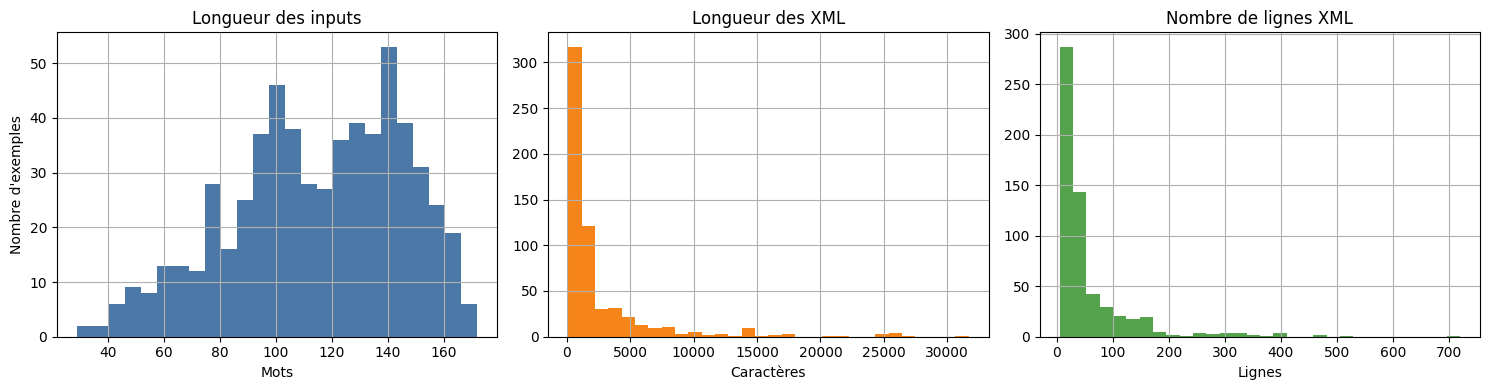

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['input_word_count'].hist(ax=axes[0], bins=25, color='#4C78A8')
axes[0].set_title('Longueur des inputs')
axes[0].set_xlabel('Mots')
axes[0].set_ylabel('Nombre d\'exemples')

df['xml_char_count'].hist(ax=axes[1], bins=30, color='#F58518')
axes[1].set_title('Longueur des XML')
axes[1].set_xlabel('Caractères')

df['xml_line_count'].hist(ax=axes[2], bins=30, color='#54A24B')
axes[2].set_title('Nombre de lignes XML')
axes[2].set_xlabel('Lignes')

plt.tight_layout()
plt.show()

Les inputs sont relativement homogènes, tandis que les XML ont une distribution très asymétrique : beaucoup de BTs courts et quelques BTs très longs. Cela indique que la difficulté principale pour le fine-tuning vient surtout de la génération XML, avec un risque de troncature pour les exemples les plus longs.

## 3. Validité syntaxique XML

On vérifie uniquement si les sorties sont parsables par `xml.etree.ElementTree`. Cette étape ne corrige pas les XML : elle sert à estimer le bruit présent dans les cibles du fine-tuning.

In [10]:
def parse_xml_safely(xml_text):
    """Parse un XML et renvoie la racine ou un message d'erreur."""
    try:
        return ET.fromstring(str(xml_text)), None
    except ET.ParseError as exc:
        return None, str(exc)


parsed_results = df['output'].apply(parse_xml_safely)
parsed_roots = parsed_results.apply(lambda result: result[0])
df['xml_parse_error'] = parsed_results.apply(lambda result: result[1])
df['xml_is_valid'] = df['xml_parse_error'].isna()

xml_validity = pd.DataFrame({
    'count': df['xml_is_valid'].value_counts().rename(index={True: 'parsable', False: 'non_parsable'}),
})
xml_validity['percent'] = (xml_validity['count'] / len(df) * 100).round(2)
xml_validity

,count,percent
xml_is_valid,,
parsable,578,97.31
non_parsable,16,2.69


In [11]:
xml_error_examples = df.loc[~df['xml_is_valid'], ['input', 'output', 'xml_parse_error']].head(8).copy()
xml_error_examples['input_preview'] = xml_error_examples['input'].str.slice(0, 180)
xml_error_examples['output_preview'] = xml_error_examples['output'].str.replace('\n', ' ', regex=False).str.slice(0, 220)

xml_error_examples[['xml_parse_error', 'input_preview', 'output_preview']]

,xml_parse_error,input_preview,output_preview
5,"not well-formed (invalid token): line 2, column 10",The behavior tree represents the decision-making process for a robot. The robot is programmed to perform a series of tasks based on cert...,"<root main_tree_to_execute=""BehaviorTree""> <!---------------------------------------> <BehaviorTree ID=""BehaviorTree""> <..."
6,"not well-formed (invalid token): line 2, column 10",The behavior tree represents a robot's task to assist in serving a drink. The robot is programmed to perform a series of actions based o...,"<root main_tree_to_execute=""BehaviorTree""> <!---------------------------------------> <BehaviorTree ID=""BehaviorTree""> <..."
47,"not well-formed (invalid token): line 2, column 10",The behavior tree outlines a task for a robot to perform in a home environment. The robot is programmed to execute a series of actions i...,"<root main_tree_to_execute=""BehaviorTree""> <!---------------------------------------> <BehaviorTree ID=""BehaviorTree""> <..."
89,"not well-formed (invalid token): line 2, column 10",The behavior tree outlines the decision-making process for a robot. The robot is programmed to perform various tasks based on certain co...,"<root main_tree_to_execute=""BehaviorTree""> <!---------------------------------------> <BehaviorTree ID=""BehaviorTree""> <..."
118,"mismatched tag: line 73, column 6",The behavior tree outlines a sequence of tasks for a robotic system. The robot is programmed to perform the following tasks in sequence:...,"<!-- Evitement <ReactiveSequence> <Fallback> <Condition ID=""NoObstacle""/> <Avoid/> </Fallback> <Move pos= positions['P2'] /> </R..."
211,"not well-formed (invalid token): line 2, column 10",The behavior tree represents the decision-making process for a robot. The robot is programmed to perform a series of actions based on ce...,"<root main_tree_to_execute=""BehaviorTree""> <!---------------------------------------> <BehaviorTree ID=""BehaviorTree""> <..."
212,"not well-formed (invalid token): line 2, column 12",The behavior tree outlines the decision-making process for a robot tasked with interacting with a ball and a bin. The robot follows a se...,"<root main_tree_to_execute=""BehaviorTree""> <!-- ----------------------------------- --> <BehaviorTree ID=""BehaviorTree""> ..."
261,"not well-formed (invalid token): line 2, column 10",The behavior tree represents a robot's task. The robot is programmed to perform a series of actions based on certain conditions and even...,"<root main_tree_to_execute=""BehaviorTree""> <!---------------------------------------> <BehaviorTree ID=""BehaviorTree""> <..."


La majorité des sorties XML sont parsables : 578 exemples sur 594, soit 97.31 %. On observe toutefois 16 exemples non parsables, principalement à cause d’erreurs de format XML comme des tokens invalides ou des balises mal appariées. Ce bruit reste minoritaire, mais il devra être pris en compte avant le fine-tuning : soit en filtrant ces exemples, soit en appliquant un nettoyage léger des commentaires XML, sans modifier le dataset source.

## 4. Vocabulaire des nœuds Behavior Tree

On extrait les tags XML pour voir quels nœuds dominent le dataset. Pour les nœuds génériques `Action`, `Condition` et `SubTree`, le vrai nom utile est souvent dans l'attribut `ID` : on compte donc aussi une forme `tag:ID`.

La séparation entre contrôle, décorateurs et actions reste approximative, car certains XML contiennent aussi des déclarations de modèle (`TreeNodesModel`, ports, etc.).

In [12]:
CONTROL_TAGS = {
    'Sequence', 'SequenceStar', 'ReactiveSequence', 'PipelineSequence', 'NonBlockingSequence',
    'Fallback', 'FallbackStar', 'ReactiveFallback', 'RecoveryNode', 'RoundRobin', 'Parallel',
}

DECORATOR_TAGS = {
    'RateController', 'DistanceController', 'SpeedController', 'Inverter', 'Repeat',
    'RetryUntilSuccessful', 'RepeatUntilFailure', 'Timeout', 'Delay', 'RunOnce',
    'ForceSuccess', 'ForceFailure', 'KeepRunningUntilFailure',
}

STRUCTURAL_TAGS = {'root', 'BehaviorTree', 'TreeNodesModel', 'input_port', 'output_port', 'inout_port'}


def extract_tags(root):
    if root is None:
        return []
    return [element.tag for element in root.iter()]


def node_display_name(element):
    """Nom lisible : tag XML, ou tag:ID pour Action/Condition/SubTree."""
    if element.tag in {'Action', 'Condition', 'SubTree'}:
        node_id = element.attrib.get('ID', '<ID_absent>')
        return f'{element.tag}:{node_id}'
    return element.tag


def extract_bt_node_display_names(root):
    if root is None:
        return []
    return [
        node_display_name(element)
        for element in root.iter()
        if element.tag not in STRUCTURAL_TAGS
    ]


tree_tag_lists = parsed_roots.apply(extract_tags)
tag_counter = Counter(tag for tags in tree_tag_lists for tag in tags)

tree_node_name_lists = parsed_roots.apply(extract_bt_node_display_names)
true_node_counter = Counter(node for nodes in tree_node_name_lists for node in nodes)

top_tags = pd.DataFrame(tag_counter.most_common(20), columns=['tag', 'count'])
top_true_nodes = pd.DataFrame(true_node_counter.most_common(25), columns=['node_name', 'count'])

print(f'Nombre total de types de tags uniques : {len(tag_counter)}')
print(f'Nombre total de vrais noms de nœuds BT uniques, hors structure/ports : {len(true_node_counter)}')
top_tags

Nombre total de types de tags uniques : 360
Nombre total de vrais noms de nœuds BT uniques, hors structure/ports : 1310


,tag,count
0,Action,5482
1,input_port,3137
2,Condition,1856
3,Sequence,1460
4,BehaviorTree,942
5,output_port,897
6,SubTree,773
7,Fallback,658
8,root,578
9,SetBlackboard,364


In [13]:
top_true_nodes

,node_name,count
0,Sequence,1460
1,Fallback,658
2,SetBlackboard,364
3,SequenceStar,328
4,Action:Move,259
5,ClearEntireCostmap,180
6,RecoveryNode,162
7,ForceSuccess,162
8,ReactiveSequence,156
9,TextToSpeechActionClient,156


Le premier tableau compte les tags XML bruts. Il est utile pour voir la structure générale du XML.
Le second tableau compte les noms de nœuds plus proches du sens BT : pour Action, Condition et SubTree, on utilise l'attribut ID.

In [14]:
def classify_tag(tag):
    if tag in CONTROL_TAGS:
        return 'controle'
    if tag in DECORATOR_TAGS:
        return 'decorateur'
    if tag in STRUCTURAL_TAGS:
        return 'structure_xml'
    if tag == 'Condition':
        return 'condition_generique'
    if tag == 'Action':
        return 'action_generique'
    return 'action_ou_noeud_metier'


tag_family_table = pd.DataFrame(
    [{'tag': tag, 'count': count, 'family': classify_tag(tag)} for tag, count in tag_counter.items()]
)

family_summary = (
    tag_family_table.groupby('family', as_index=False)
    .agg(unique_tags=('tag', 'nunique'), total_occurrences=('count', 'sum'))
    .sort_values('total_occurrences', ascending=False)
)

family_summary

,family,unique_tags,total_occurrences
5,structure_xml,6,6088
0,action_generique,1,5482
1,action_ou_noeud_metier,331,4023
3,controle,10,3171
2,condition_generique,1,1856
4,decorateur,11,902


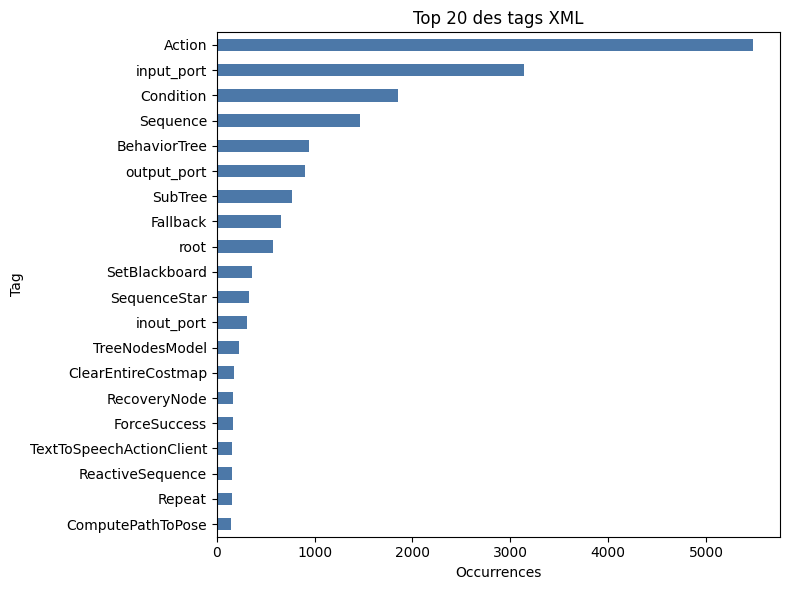

In [15]:
top_tags.sort_values('count').plot(
    kind='barh', x='tag', y='count', figsize=(8, 6), legend=False, color='#4C78A8'
)
plt.title('Top 20 des tags XML')
plt.xlabel('Occurrences')
plt.ylabel('Tag')
plt.tight_layout()
plt.show()

## 5. Attributs, ports et variables Blackboard

Les XML BT ne sont pas seulement une liste de tags : les attributs portent les paramètres, les ports décrivent les interfaces des nœuds, et les variables entre accolades comme `{goal}` ou `{path}` indiquent des échanges via Blackboard. Cette analyse aide à préparer une future validation plus stricte pour NAV4RAIL/SNCF.

In [16]:
BLACKBOARD_VARIABLE_RE = re.compile(r'\{[A-Za-z_][A-Za-z0-9_./:-]*\}')

attribute_counter = Counter()
attribute_value_counter = Counter()
port_counter = Counter()
blackboard_variable_counter = Counter()

for root in parsed_roots.dropna():
    for element in root.iter():
        for attr_name, attr_value in element.attrib.items():
            attr_value = str(attr_value)
            attribute_counter[attr_name] += 1
            attribute_value_counter[(attr_name, attr_value)] += 1
            blackboard_variable_counter.update(BLACKBOARD_VARIABLE_RE.findall(attr_value))

        if element.tag in {'input_port', 'output_port', 'inout_port'}:
            port_name = element.attrib.get('name', '<nom_absent>')
            port_counter[(element.tag, port_name)] += 1

# Recherche dans le texte XML brut seulement pour les exemples non parsables.
for xml_text in df.loc[~df['xml_is_valid'], 'output']:
    blackboard_variable_counter.update(BLACKBOARD_VARIABLE_RE.findall(str(xml_text)))

top_attributes = pd.DataFrame(attribute_counter.most_common(20), columns=['attribute', 'count'])
top_attribute_values = pd.DataFrame(
    [
        {'attribute': attr, 'value': value, 'count': count}
        for (attr, value), count in attribute_value_counter.most_common(20)
    ]
)
top_ports = pd.DataFrame(
    [
        {'port_type': port_type, 'port_name': port_name, 'count': count}
        for (port_type, port_name), count in port_counter.most_common(20)
    ]
)
top_blackboard_variables = pd.DataFrame(
    blackboard_variable_counter.most_common(25), columns=['variable', 'count']
)

top_attributes

,attribute,count
0,ID,9158
1,name,6828
2,type,1692
3,default,970
4,main_tree_to_execute,578
5,value,421
6,output_key,364
7,goal,349
8,path,349
9,service_name,317


Contrairement au graphique des tags, ce tableau ne compte pas les nœuds XML mais les attributs portés par ces nœuds. Il montre quels paramètres sont importants dans le dataset, par exemple `ID`, `name`, `goal`, `path`, `service_name`.

## 6. Complexité des Behavior Trees

La complexité est estimée avec des métriques simples : nombre d'éléments XML utiles, profondeur maximale, nombre de nœuds de contrôle, décorateurs et sous-arbres.

In [19]:
META_TAGS_FOR_COMPLEXITY = {'TreeNodesModel', 'input_port', 'output_port', 'inout_port'}


def max_depth(element, current_depth=0):
    """Calcule la profondeur maximale depuis la racine XML."""
    children = list(element)
    if not children:
        return current_depth
    return max(max_depth(child, current_depth + 1) for child in children)


def count_useful_nodes(root):
    return sum(1 for element in root.iter() if element.tag not in META_TAGS_FOR_COMPLEXITY)


def count_tags(root, tags):
    return sum(1 for element in root.iter() if element.tag in tags)


complexity_columns = [
    'bt_node_count', 'bt_max_depth', 'sequence_count', 'fallback_count', 'decorator_count', 'subtree_count'
]

for column in complexity_columns:
    df[column] = pd.NA

for idx, root in parsed_roots.items():
    if root is None:
        continue
    df.loc[idx, 'bt_node_count'] = count_useful_nodes(root)
    df.loc[idx, 'bt_max_depth'] = max_depth(root)
    df.loc[idx, 'sequence_count'] = count_tags(root, {'Sequence', 'SequenceStar', 'ReactiveSequence', 'PipelineSequence', 'NonBlockingSequence'})
    df.loc[idx, 'fallback_count'] = count_tags(root, {'Fallback', 'FallbackStar', 'ReactiveFallback', 'RecoveryNode'})
    df.loc[idx, 'decorator_count'] = count_tags(root, DECORATOR_TAGS)
    df.loc[idx, 'subtree_count'] = count_tags(root, {'SubTree'})

for column in complexity_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce').astype('Int64')

complexity_stats = df.loc[df['xml_is_valid'], complexity_columns].astype(float).describe().loc[['mean', '50%', 'min', 'max']].T.round(2)
complexity_stats = complexity_stats.rename(columns={'50%': 'median'})
complexity_stats

,mean,median,min,max
bt_node_count,29.33,15.0,3.0,399.0
bt_max_depth,5.40,5.0,2.0,21.0
sequence_count,3.56,2.0,0.0,76.0
fallback_count,1.75,0.0,0.0,27.0
decorator_count,1.56,1.0,0.0,49.0
subtree_count,1.34,0.0,0.0,53.0


In [20]:
def complexity_bucket(node_count):
    if pd.isna(node_count):
        return 'non_parsable'
    if node_count <= 20:
        return 'simple_<=20_noeuds'
    if node_count <= 60:
        return 'moyen_21_60_noeuds'
    return 'complexe_>60_noeuds'


df['bt_complexity_bucket'] = df['bt_node_count'].apply(complexity_bucket)

bucket_table = (
    df['bt_complexity_bucket']
    .value_counts()
    .rename_axis('complexity_bucket')
    .reset_index(name='count')
)
bucket_table['percent'] = (bucket_table['count'] / len(df) * 100).round(2)
bucket_table

,complexity_bucket,count,percent
0,simple_<=20_noeuds,361,60.77
1,moyen_21_60_noeuds,161,27.10
2,complexe_>60_noeuds,56,9.43
3,non_parsable,16,2.69


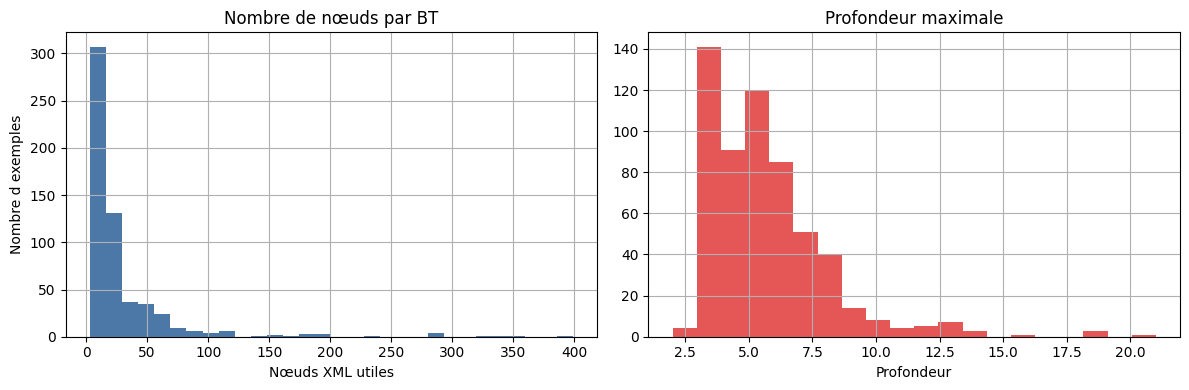

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.loc[df['xml_is_valid'], 'bt_node_count'].dropna().astype(int).hist(ax=axes[0], bins=30, color='#4C78A8')
axes[0].set_title('Nombre de nœuds par BT')
axes[0].set_xlabel('Nœuds XML utiles')
axes[0].set_ylabel('Nombre d exemples')

df.loc[df['xml_is_valid'], 'bt_max_depth'].dropna().astype(int).hist(ax=axes[1], bins=20, color='#E45756')
axes[1].set_title('Profondeur maximale')
axes[1].set_xlabel('Profondeur')

plt.tight_layout()
plt.show()

Ces graphes confirment que la complexité des BTs est très déséquilibrée : beaucoup d’arbres sont courts et peu profonds, mais quelques exemples contiennent beaucoup de nœuds et une forte profondeur. Pour le fine-tuning, ces cas extrêmes peuvent être plus difficiles à apprendre et risquent de produire plus d’erreurs XML ou structurelles.

## 7. Catégories approximatives

**Important : ces catégories sont heuristiques.** Le dataset ne contient pas de colonne métier dédiée. On propose donc une catégorisation multi-label par mots-clés dans l'input et l'output : elle sert uniquement à explorer les tendances, pas à produire une vérité métier ou une taxonomie SNCF.

In [22]:
CATEGORY_PATTERNS = {
    'navigation': [r'\bnavigat\w*\b', r'\bpath\b', r'\bplanner\b', r'\bgoal\b', r'\bwaypoint\b', r'\bcostmap\b', r'\bdock\w*\b'],
    'manipulation': [r'\bmanipulat\w*\b', r'\barm\b', r'\bpick\b', r'\bplace\b', r'\bgrasp\b', r'\bobject\b', r'\baruco\b', r'\bbutton\b'],
    'exploration': [r'\bexplor\w*\b', r'\bfrontier\b', r'\bmap\b', r'\bscan\b', r'\bunknown\b'],
    'fallback': [r'\bfallback\b', r'\brecover\w*\b', r'\brecovery\b', r'\bretry\b', r'\btimeout\b'],
    'assembly': [r'\bassembl\w*\b', r'\bscrew\w*\b', r'\bbolt\w*\b', r'\bgearbox\b'],
    'material_processing': [r'\bdrill\w*\b', r'\bweld\w*\b', r'\bpaint\w*\b', r'\bpolish\w*\b', r'\bmilling\b', r'\bmaterial\b', r'\bcut\b'],
}


def categorize_example(input_text, output_text):
    text = f'{input_text}\n{output_text}'.lower()
    categories = []
    for category, patterns in CATEGORY_PATTERNS.items():
        if any(re.search(pattern, text) for pattern in patterns):
            categories.append(category)
    return categories if categories else ['other']


df['approx_categories'] = df.apply(lambda row: categorize_example(row['input'], row['output']), axis=1)

category_counter = Counter(category for categories in df['approx_categories'] for category in categories)
category_table = pd.DataFrame(category_counter.most_common(), columns=['category', 'count'])
category_table['percent_of_examples'] = (category_table['count'] / len(df) * 100).round(2)
category_table

,category,count,percent_of_examples
0,navigation,370,62.29
1,fallback,274,46.13
2,manipulation,135,22.73
3,other,94,15.82
4,exploration,52,8.75
5,assembly,1,0.17


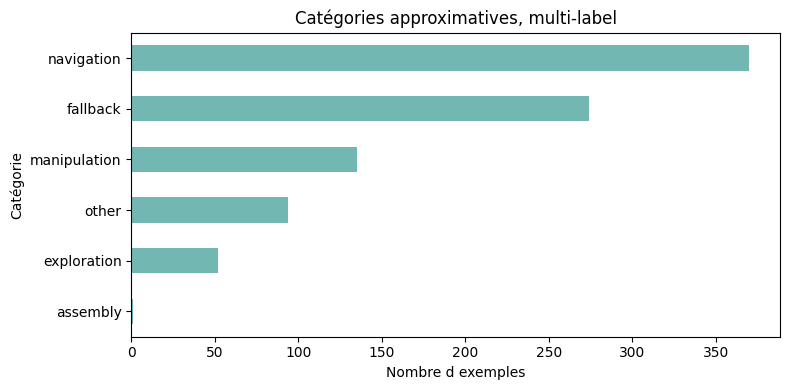

In [23]:
category_table.sort_values('count').plot(
    kind='barh', x='category', y='count', figsize=(8, 4), legend=False, color='#72B7B2'
)
plt.title('Catégories approximatives, multi-label')
plt.xlabel('Nombre d exemples')
plt.ylabel('Catégorie')
plt.tight_layout()
plt.show()

## 8. Lien avec NAV4RAIL/SNCF

**BTGenBot** travaille avec un vocabulaire robotique assez ouvert, des Behavior Trees publics proches de l'écosystème ROS2/BehaviorTree.CPP, et des sorties XML statiques. Le dataset est utile pour apprendre la relation entre une description naturelle et une structure BT.

**NAV4RAIL/SNCF** vise un cadre plus contraint : catalogue fermé de skills, ports typés, règles métier, templates paramétrés par fichier mission, et validation plus forte avant exécution.

Ce qui semble transférable :
- le format général instruction + entrée naturelle + sortie structurée ;
- la logique de fine-tuning sur des paires texte/XML ;
- les étapes de validation syntaxique et d'analyse des erreurs ;
- l'étude de la complexité des arbres pour anticiper les limites du modèle.

Ce qui devra être adapté :
- remplacer les actions BTGenBot par les skills SNCF/NAV4RAIL autorisés ;
- imposer les ports typés et les paramètres métier ;
- intégrer les templates de missions ferroviaires ;
- ajouter des règles de validation spécifiques au domaine avant toute génération exploitable.

## 9. Conclusion de l'EDA

Cette cellule calcule les chiffres clés à réutiliser dans le rapport ou dans la discussion de transfert.

In [24]:
key_figures = pd.DataFrame([
    {'metric': 'Nombre total d exemples', 'value': len(df)},
    {'metric': 'XML parsables', 'value': int(df['xml_is_valid'].sum())},
    {'metric': 'XML non parsables', 'value': int((~df['xml_is_valid']).sum())},
    {'metric': 'Médiane des mots input', 'value': float(df['input_word_count'].median())},
    {'metric': 'Médiane des nœuds BT parsables', 'value': float(df.loc[df['xml_is_valid'], 'bt_node_count'].median())},
])

key_figures

,metric,value
0,Nombre total d exemples,594.0
1,XML parsables,578.0
2,XML non parsables,16.0
3,Médiane des mots input,117.5
4,Médiane des nœuds BT parsables,15.0


**3 observations importantes**

- Le dataset est propre côté champs : les colonnes attendues sont présentes et il n'y a pas de valeurs manquantes visibles.
- Les XML ne sont pas tous parsables, ce qui peut injecter du bruit dans l'apprentissage si on ne filtre pas ou si on ne documente pas ces cas.
- Les Behavior Trees ont des tailles très variables : certains exemples sont courts, d'autres beaucoup plus longs et profonds.

**2 risques pour le fine-tuning**

- Le modèle peut apprendre des XML syntaxiquement invalides si les exemples bruités restent dans le dataset final.
- Les très longs XML peuvent dépasser les limites de contexte ou être plus difficiles à reproduire fidèlement.

## 10. Conversion JSONL et adaptation du prompt

On prépare le format d'entraînement, mais on ne lance pas de fine-tuning ici.

On produit deux vues JSONL :
- une version `all_with_status` avec les 594 exemples et un statut XML pour l'audit ;
- une version `clean_parsable` recommandée pour un premier fine-tuning, avec seulement les XML parsables.

Le prompt ci-dessous reste volontairement aligné avec BTGenBot. On ne force pas encore les contraintes NAV4RAIL/SNCF dans les exemples d'entraînement, car les sorties du dataset ne respectent pas un catalogue SNCF fermé.

In [25]:
PROMPT_VERSION = 'btgenbot_xml_v1'

BTGENBOT_PROMPT_INSTRUCTION = (
    'You are a robotics assistant specialized in Behavior Trees. '
    'Given a natural-language task description, generate the corresponding Behavior Tree in XML format. '
    'Return only valid XML, without Markdown fences, explanations, or extra text.'
)


def normalize_text(text):
    return str(text).strip()


def safe_int(value):
    if pd.isna(value):
        return None
    return int(value)


def build_jsonl_record(row, original_index):
    categories = row.get('approx_categories', [])
    if not isinstance(categories, list):
        categories = [str(categories)]

    return {
        'instruction': BTGENBOT_PROMPT_INSTRUCTION,
        'input': normalize_text(row['input']),
        'output': normalize_text(row['output']),
        'metadata': {
            'source': 'BTGenBot',
            'prompt_version': PROMPT_VERSION,
            'original_index': int(original_index),
            'xml_status': 'parsable' if bool(row['xml_is_valid']) else 'non_parsable',
            'approx_categories': categories,
            'input_word_count': safe_int(row['input_word_count']),
            'xml_char_count': safe_int(row['xml_char_count']),
            'xml_line_count': safe_int(row['xml_line_count']),
            'bt_node_count': safe_int(row['bt_node_count']),
            'bt_max_depth': safe_int(row['bt_max_depth']),
        },
    }


print(BTGENBOT_PROMPT_INSTRUCTION)

You are a robotics assistant specialized in Behavior Trees. Given a natural-language task description, generate the corresponding Behavior Tree in XML format. Return only valid XML, without Markdown fences, explanations, or extra text.


In [26]:
jsonl_all_records = [
    build_jsonl_record(row, original_index=idx)
    for idx, row in df.iterrows()
]

jsonl_clean_records = [
    build_jsonl_record(row, original_index=idx)
    for idx, row in df.loc[df['xml_is_valid']].iterrows()
]

jsonl_summary = pd.DataFrame([
    {
        'jsonl_view': 'all_with_status',
        'examples': len(jsonl_all_records),
        'use_for_first_finetuning': 'non, audit seulement',
        'reason': 'contient aussi les XML non parsables',
    },
    {
        'jsonl_view': 'clean_parsable',
        'examples': len(jsonl_clean_records),
        'use_for_first_finetuning': 'oui',
        'reason': 'garde uniquement les cibles XML parsables',
    },
])

display(jsonl_summary)

preview_record = jsonl_clean_records[0].copy()
preview_record['output'] = preview_record['output'][:700] + '\n[...]'
print(json.dumps(preview_record, ensure_ascii=False, indent=2))

,jsonl_view,examples,use_for_first_finetuning,reason
0,all_with_status,594,"non, audit seulement",contient aussi les XML non parsables
1,clean_parsable,578,oui,garde uniquement les cibles XML parsables


{
  "instruction": "You are a robotics assistant specialized in Behavior Trees. Given a natural-language task description, generate the corresponding Behavior Tree in XML format. Return only valid XML, without Markdown fences, explanations, or extra text.",
  "input": "The behavior tree orchestrates the navigation of a robot by periodically replanning its global path at a frequency of 1 Hz. It utilizes a pipeline sequence, where it first computes a path to a specified goal using a \"GridBased\" planner and then follows this computed path using a designated controller. This approach ensures that the robot continuously updates its path to adapt to dynamic environments or changing conditions, enabling it to navigate effectively towards its goal while avoiding obstacles or other potential disruptions.",
  "output": "<!--\n  This Behavior Tree replans the global path periodically at 1 Hz.\n-->\n\n<root main_tree_to_execute=\"MainTree\">\n  <BehaviorTree ID=\"MainTree\">\n    <PipelineSequen

In [27]:
def write_jsonl(records, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with output_path.open('w', encoding='utf-8') as f:
        for record in records:
            f.write(json.dumps(record, ensure_ascii=False) + '\n')
    return output_path


# Sortie volontairement dans /tmp pour ne pas ajouter de fichiers générés au repo.
JSONL_OUTPUT_DIR = Path('/tmp') / 'btgenbot_mohamed_jsonl'

all_jsonl_path = write_jsonl(
    jsonl_all_records,
    JSONL_OUTPUT_DIR / 'btgenbot_all_with_xml_status.jsonl',
)

clean_jsonl_path = write_jsonl(
    jsonl_clean_records,
    JSONL_OUTPUT_DIR / 'btgenbot_clean_parsable_for_qlora.jsonl',
)

print(f'JSONL audit écrit : {all_jsonl_path} ({len(jsonl_all_records)} exemples)')
print(f'JSONL recommandé fine-tuning écrit : {clean_jsonl_path} ({len(jsonl_clean_records)} exemples)')

JSONL audit écrit : /tmp/btgenbot_mohamed_jsonl/btgenbot_all_with_xml_status.jsonl (594 exemples)
JSONL recommandé fine-tuning écrit : /tmp/btgenbot_mohamed_jsonl/btgenbot_clean_parsable_for_qlora.jsonl (578 exemples)


**Choix recommandé pour la suite**

Pour un premier fine-tuning QLoRA, utiliser `btgenbot_clean_parsable_for_qlora.jsonl`, car il garde uniquement les sorties XML parsables. La version `all_with_xml_status` reste utile pour l'audit et pour comparer plus tard une stratégie de nettoyage des 16 XML invalides.

L'adaptation NAV4RAIL/SNCF ne doit pas être mélangée trop tôt avec ce JSONL BTGenBot : il faudra d'abord disposer du catalogue de skills SNCF, des ports typés et des règles de validation.